# Week 7 - Function 3 ((21DP, 3D, 2D active [x2,x3]))

# Setup
Let's load all the imports in the top to avoid repeating and simplify the readability of each solution.

In [1]:

import numpy as np

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from sklearn.preprocessing import StandardScaler, MinMaxScaler, QuantileTransformer
from sklearn.svm import SVC, SVR
from scipy.stats.qmc import LatinHypercube

from utils.plotting_utils import (
    plot_bar,
    plot_bar_diff,
    plot_3D_mean_uncertainty_slice,
    plot_svm_analysis_slice,
    plot_acquisition_comparison_slice
)


# Plan
We now have ((21, 3)) — 21 data points, 3 dimensions, from `./data/week_7/function_3/`.

**Architecture**: Dual-GP ensemble (QT + log10) with SVM-constrained UCB.

**Key decisions** (carried forward):
- QuantileTransformer + log10 shift: all-negative outputs, compressed range
- UCB kappa=3.615 (budget-aware: week 7/13)
- SVM C=1 soft margin, median threshold, fail-safe at <5% coverage
- **Active subspace**: x1 confirmed noise this week (ls=1000, ceiling in gp_qt; ls=16.88 in gp_log). LHS search runs in 2D (x2, x3); x1 fixed at training mean. GPs and SVM still operate in full 3D.

**Changes / fixes this week:**
- **Critical**: SVM threshold fixed from `yi > -50` → `yi > np.median(y_log_pos)`. The old threshold labelled all 17 points as "promising" (y_log_pos ∈ [-1.16, -0.78], all above -50), giving 100% SVM coverage and making the constraint useless. Corrected to match the Fn5/6/7 median pattern.
- kappa updated from 5.0 → 3.615 (budget-aware: week 7/13)
- `length_scale_bounds` upper raised 50 → 1e3 (confirmed x1 as noise dim)
- **x1 dropped from LHS search**: 2D active subspace (x2, x3); x1 fixed at `X_train[:,0].mean()`

**Steps:** Load data → Preprocessing → GP models → SVM → Acquisition (2D active LHS) → Report

# 1. Load data

In [2]:

X_train_raw = np.load(r"./data/week_7/function_3/inputs.npy")
y_train_raw = np.load(r"./data/week_7/function_3/outputs.npy")

print(f"Shape: X={X_train_raw.shape}, y={y_train_raw.shape}")
print(f"X range: [{X_train_raw.min():.4f}, {X_train_raw.max():.4f}]")
print(f"y range: [{y_train_raw.min():.2e}, {y_train_raw.max():.2e}]")


Shape: X=(21, 3), y=(21,)
X range: [0.0468, 0.9909]
y range: [-3.99e-01, -2.24e-02]


# 2. Preprocessing

The output data contains a significant negative outlier, similar to other functions. `StandardScaler` is ineffective in this scenario as it collapses the variance of the non-outlier points. We will use `QuantileTransformer` to rank the data and spread it uniformly, and also a `log10` transform for positive-only points to model the magnitude differences.

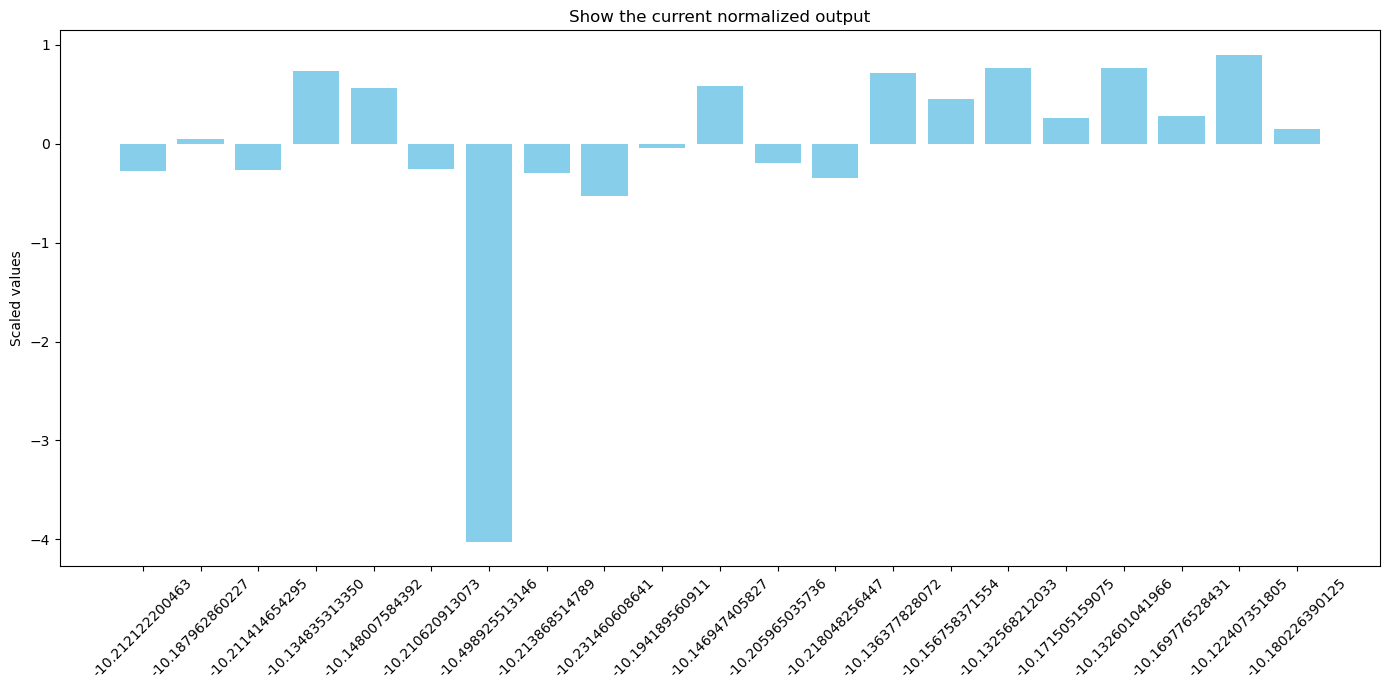

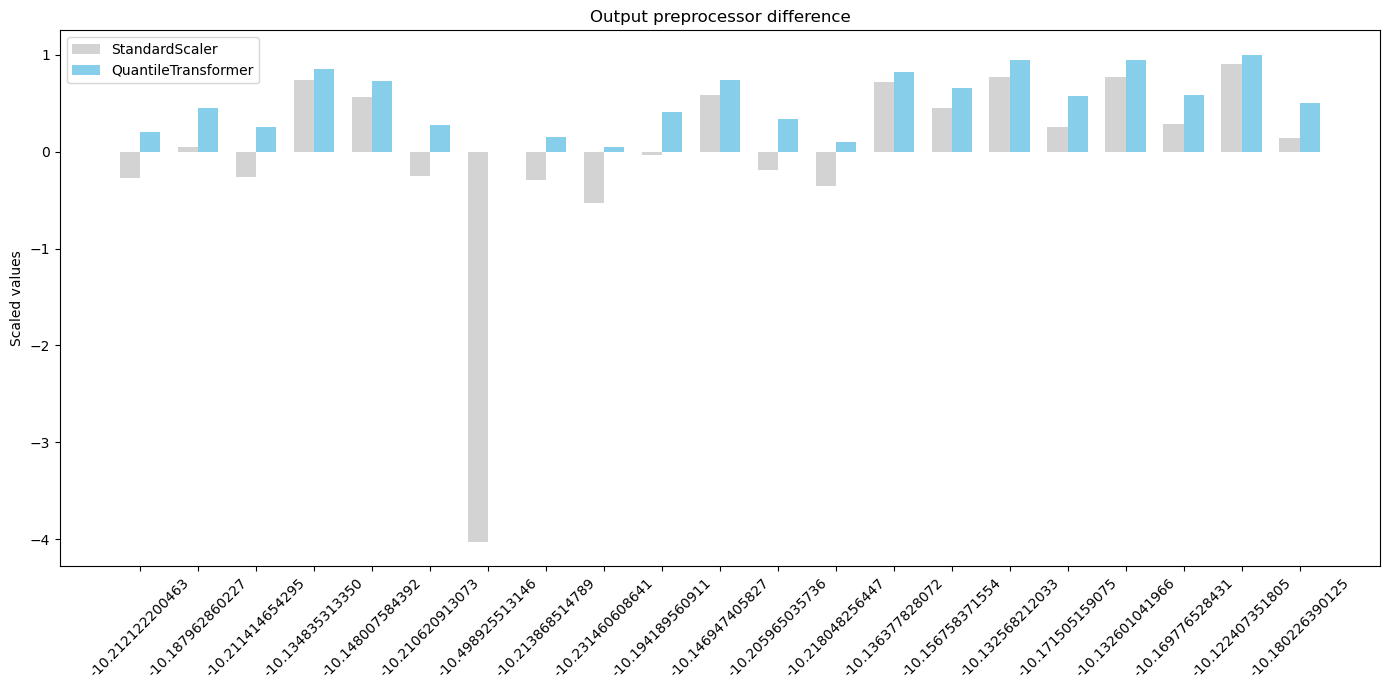

Total points: 21
Range for new normalized output: [0.0, 1.0]
Best point: X=[0.848043 0.465799 0.395813], y=-2.24e-02, QuantileTransformer(y)=1.0

Log shift constant: 1.40
All 21 points included in log space
log10(y_shifted) range: [0.0000, 0.1388]


In [3]:
scaler_X = MinMaxScaler()
X_train = scaler_X.fit_transform(X_train_raw)

scaler_ss = StandardScaler()
y_ss = scaler_ss.fit_transform(y_train_raw.reshape(-1, 1)).ravel()

scaler_qt = QuantileTransformer(n_quantiles=len(y_train_raw)-1, output_distribution='uniform')
y_qt = scaler_qt.fit_transform(y_train_raw.reshape(-1, 1)).ravel()

plot_bar(y_train_raw, y_ss, 'Scaled values', 'Show the current normalized output')

plot_bar_diff(y_train_raw, y_ss, y_qt, 'StandardScaler', 'QuantileTransformer', 'Scaled values', 'Output preprocessor difference')

print(f"Total points: {len(X_train)}")
print(f"Range for new normalized output: [{y_qt.min():.1f}, {y_qt.max():.1f}]")
print(f"Best point: X={X_train_raw[np.argmax(y_train_raw)]}, y={y_train_raw.max():.2e}, QuantileTransformer(y)={y_qt.max():.1f}")

# Log transform: shift by abs(min)+1 guarantees all points positive (min shifted = 1.0).
# Previous shift of 0.2 was insufficient for y_min=-0.399, excluding some training points.
log_shift_constant = abs(y_train_raw.min()) + 1.0
y_train_raw_shifted = y_train_raw + log_shift_constant
X_train_pos = X_train              # all points (no masking needed)
y_log_pos = np.log10(y_train_raw_shifted)

print(f"\nLog shift constant: {log_shift_constant:.2f}")
print(f"All {len(y_train_raw)} points included in log space")
print(f"log10(y_shifted) range: [{y_log_pos.min():.4f}, {y_log_pos.max():.4f}]")

# 3. Build probabilistic Models

We build two GP models with different preprocessing to create a more robust ensemble:
- **gp_qt** (QuantileTransformer, all 21 points): Models the rank-transformed data.
- **gp_log** (log10, positive points): Models the output magnitude in log-space.

/opt/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


GP(QT) kernel: 1.17**2 * Matern(length_scale=[1e+03, 0.727, 0.15], nu=2.5)
GP(log) kernel: 1.77**2 * Matern(length_scale=[16.9, 1.68, 0.136], nu=2.5)

GP(QT) length scales: [1.00000000e+03 7.27131609e-01 1.50346019e-01]
  x3: ls=0.1503, importance=82.9%, IMPORTANT
  x2: ls=0.7271, importance=17.1%, IMPORTANT
  x1: ls=1000.0000, importance=0.0%, noise

GP(log) length scales: [16.87687103  1.68276366  0.13558985]
  x3: ls=0.1356, importance=91.9%, IMPORTANT
  x2: ls=1.6828, importance=7.4%, moderate
  x1: ls=16.8769, importance=0.7%, noise


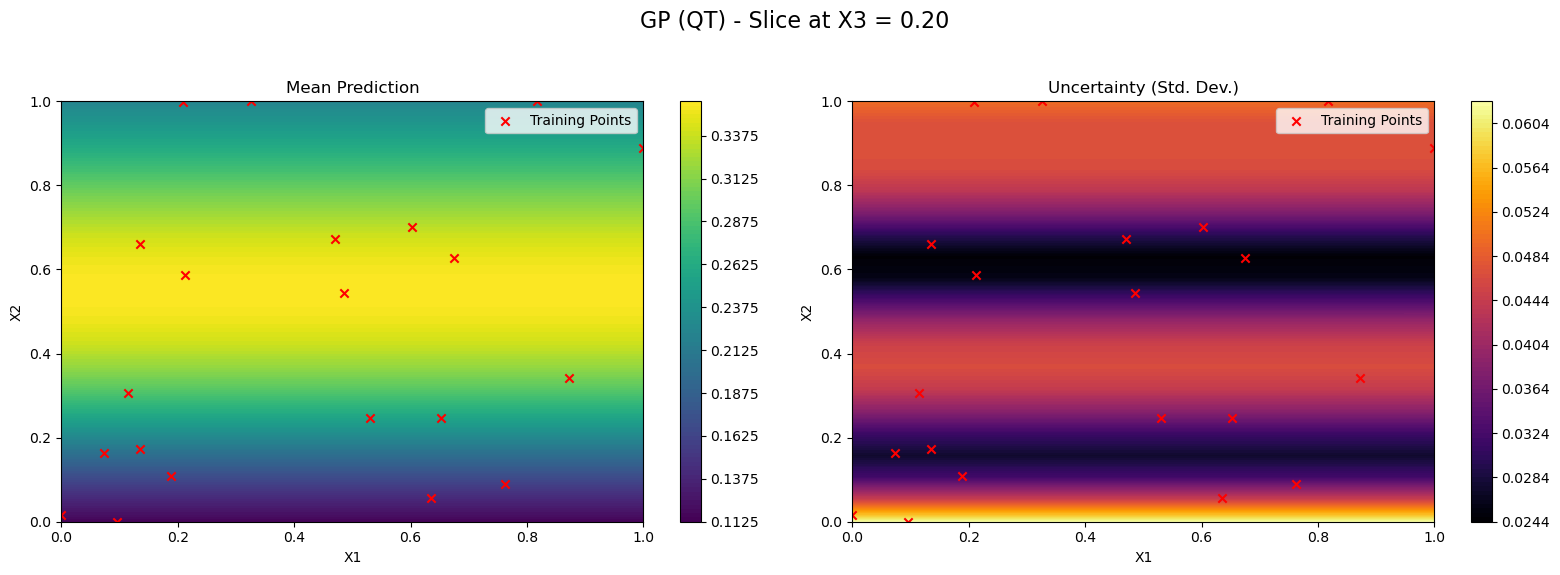

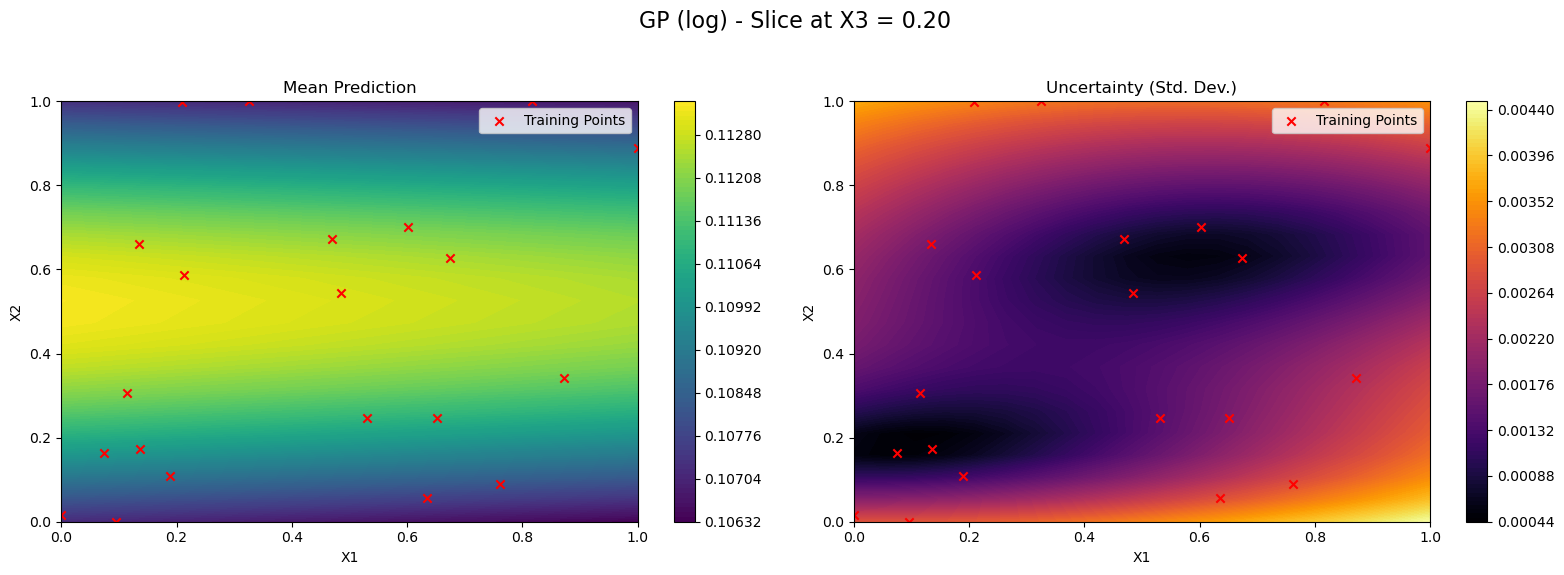

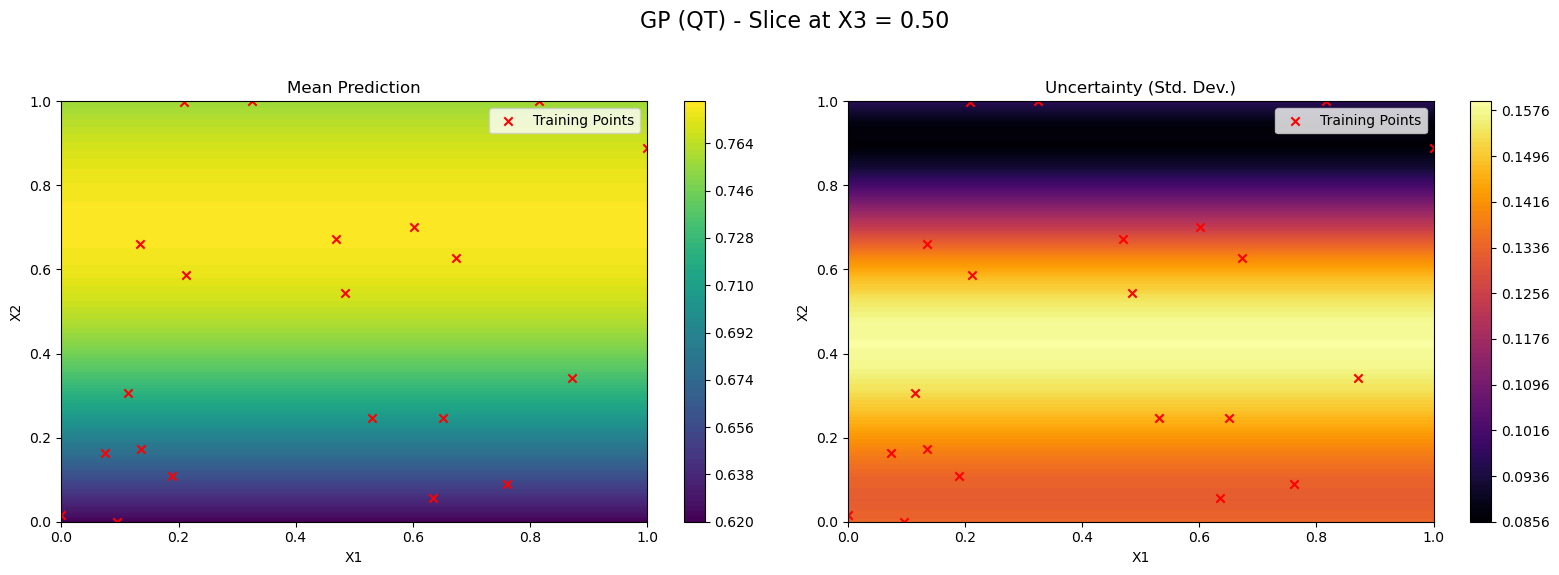

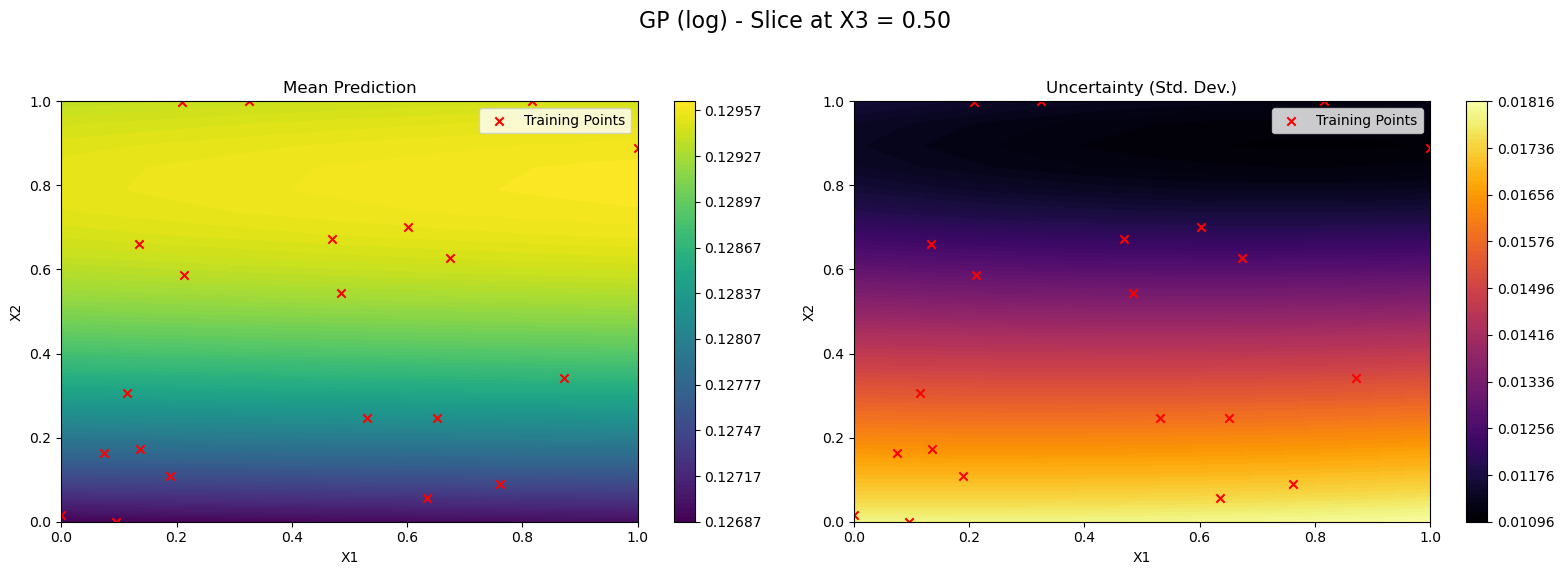

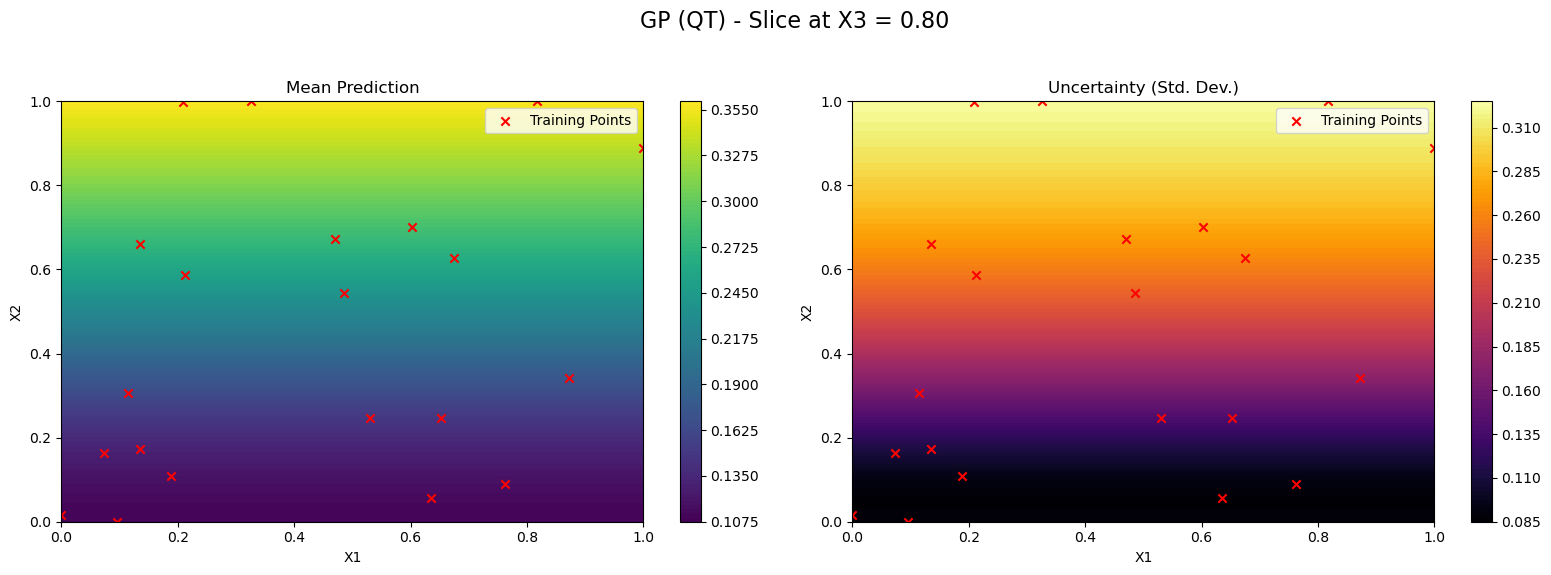

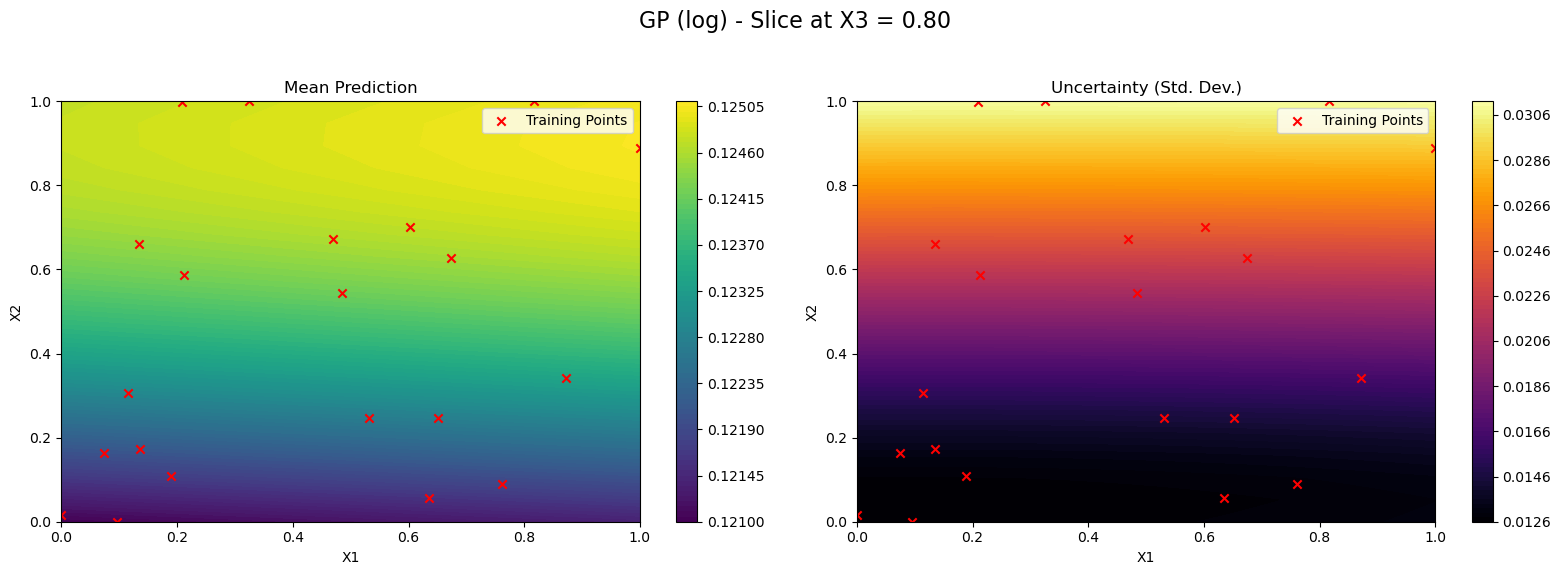

In [4]:
# GP on QuantileTransformer output (all points) — ARD kernel
gp_qt = GaussianProcessRegressor(
    kernel=ConstantKernel(0.25, (1e-3, 10)) * Matern(
        length_scale=[0.5, 0.5, 0.5],
        nu=2.5,
        length_scale_bounds=(0.05, 1e3)
    ),
    alpha=0.01,
    normalize_y=True,
    n_restarts_optimizer=30,
    optimizer='fmin_l_bfgs_b'
)

# GP in log-space on all points (shift guarantees all positive) — ARD kernel
gp_log = GaussianProcessRegressor(
    kernel=ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
        length_scale=[0.3, 0.3, 0.3],
        nu=2.5,
        length_scale_bounds=(1e-3, 1e3)
    ),
    alpha=1e-4,
    normalize_y=True,
    n_restarts_optimizer=50
)

gp_qt.fit(X_train, y_qt)
gp_log.fit(X_train, y_log_pos)

print(f"GP(QT) kernel: {gp_qt.kernel_}")
print(f"GP(log) kernel: {gp_log.kernel_}")

# Feature importance from ARD length scales
for name, gp in [('GP(QT)', gp_qt), ('GP(log)', gp_log)]:
    ls = gp.kernel_.k2.length_scale
    imp = 1.0 / ls
    imp_norm = imp / imp.sum() * 100
    print(f"\n{name} length scales: {ls}")
    sorted_dims = np.argsort(ls)
    for i in sorted_dims:
        role = 'IMPORTANT' if ls[i] < 1.0 else ('moderate' if ls[i] < 5.0 else 'noise')
        print(f"  x{i+1}: ls={ls[i]:.4f}, importance={imp_norm[i]:.1f}%, {role}")

# Create prediction grid (kept for visualization)
n_grid = 20
x1_range = np.linspace(0, 1, n_grid)
x2_range = np.linspace(0, 1, n_grid)
x3_range = np.linspace(0, 1, n_grid)
X1_test, X2_test, X3_test = np.meshgrid(x1_range, x2_range, x3_range)
X_grid = np.c_[X1_test.ravel(), X2_test.ravel(), X3_test.ravel()]

# 2D slice plotting
def plot_gp_slices(x3_slice):
    grid_slice = np.c_[X_grid[:, 0], X_grid[:, 1], np.full_like(X_grid[:, 0], x3_slice)]

    mu_gp_qt, sigma_gp_qt = gp_qt.predict(grid_slice, return_std=True)
    mu_gp_log, sigma_gp_log = gp_log.predict(grid_slice, return_std=True)

    plot_3D_mean_uncertainty_slice(
        X_train, X1_test[:,:,0], X2_test[:,:,0],
        mu_gp_qt.reshape(n_grid, n_grid, n_grid)[:,:, int(x3_slice*(n_grid-1))],
        sigma_gp_qt.reshape(n_grid, n_grid, n_grid)[:,:, int(x3_slice*(n_grid-1))],
        title_prefix="GP (QT)", x3_slice_val=x3_slice
    )
    plot_3D_mean_uncertainty_slice(
        X_train, X1_test[:,:,0], X2_test[:,:,0],
        mu_gp_log.reshape(n_grid, n_grid, n_grid)[:,:, int(x3_slice*(n_grid-1))],
        sigma_gp_log.reshape(n_grid, n_grid, n_grid)[:,:, int(x3_slice*(n_grid-1))],
        title_prefix="GP (log)", x3_slice_val=x3_slice
    )

for x3_val in [0.2, 0.5, 0.8]:
    plot_gp_slices(x3_val)

# 4. SVM Analysis

To handle the penalty zone (negative outputs) and create a more diverse model ensemble, we use three SVMs:
1. **SVM Classifier**: Learns the boundary between 'promising' (positive output) and 'unpromising' (negative output) regions.
2. **SVR Surrogate (log-space)**: An independent surrogate model trained on the log-transformed positive outputs.
3. **SVR Surrogate (QuantileTransformer)**: A second independent surrogate trained on the quantile-transformed outputs.

SVM threshold: 0.1201 | 10 promising / 11 not promising

=== Support Vectors: 20 / 21 training points ===
 Idx         Label        x1        x2        x3         y_raw
   0           not    0.1715    0.3439    0.2487     -0.112122
   1           not    0.2421    0.6441    0.2724     -0.087963
   2           not    0.5349    0.3985    0.1734     -0.111415
   5           not    0.3455    0.9414    0.2694     -0.110621
   7           not    0.6455    0.3971    0.9198     -0.113869
   8           not    0.7469    0.2842    0.2263     -0.131461
   9           not    0.1705    0.6970    0.1492     -0.094190
  11           not    0.6660    0.6720    0.2463     -0.105965
  12           not    0.0468    0.2314    0.7706     -0.118048
  20           not    0.1148    0.3381    0.6218     -0.080226
   3     promising    0.4926    0.6116    0.3402     -0.034835
   4     promising    0.1346    0.2199    0.4582     -0.048008
  10     promising    0.2205    0.2978    0.3436     -0.046947
  13     pro

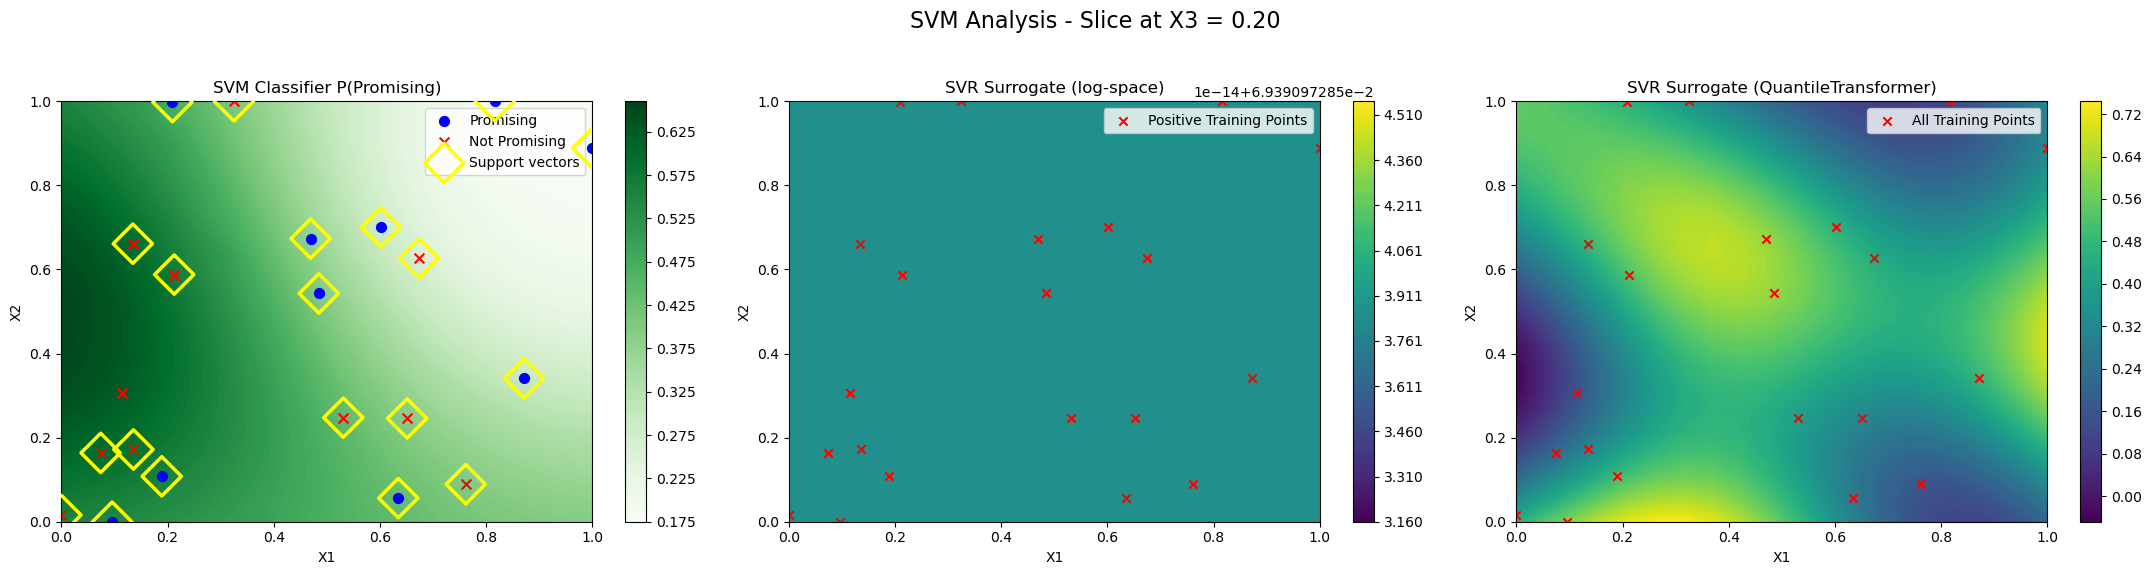

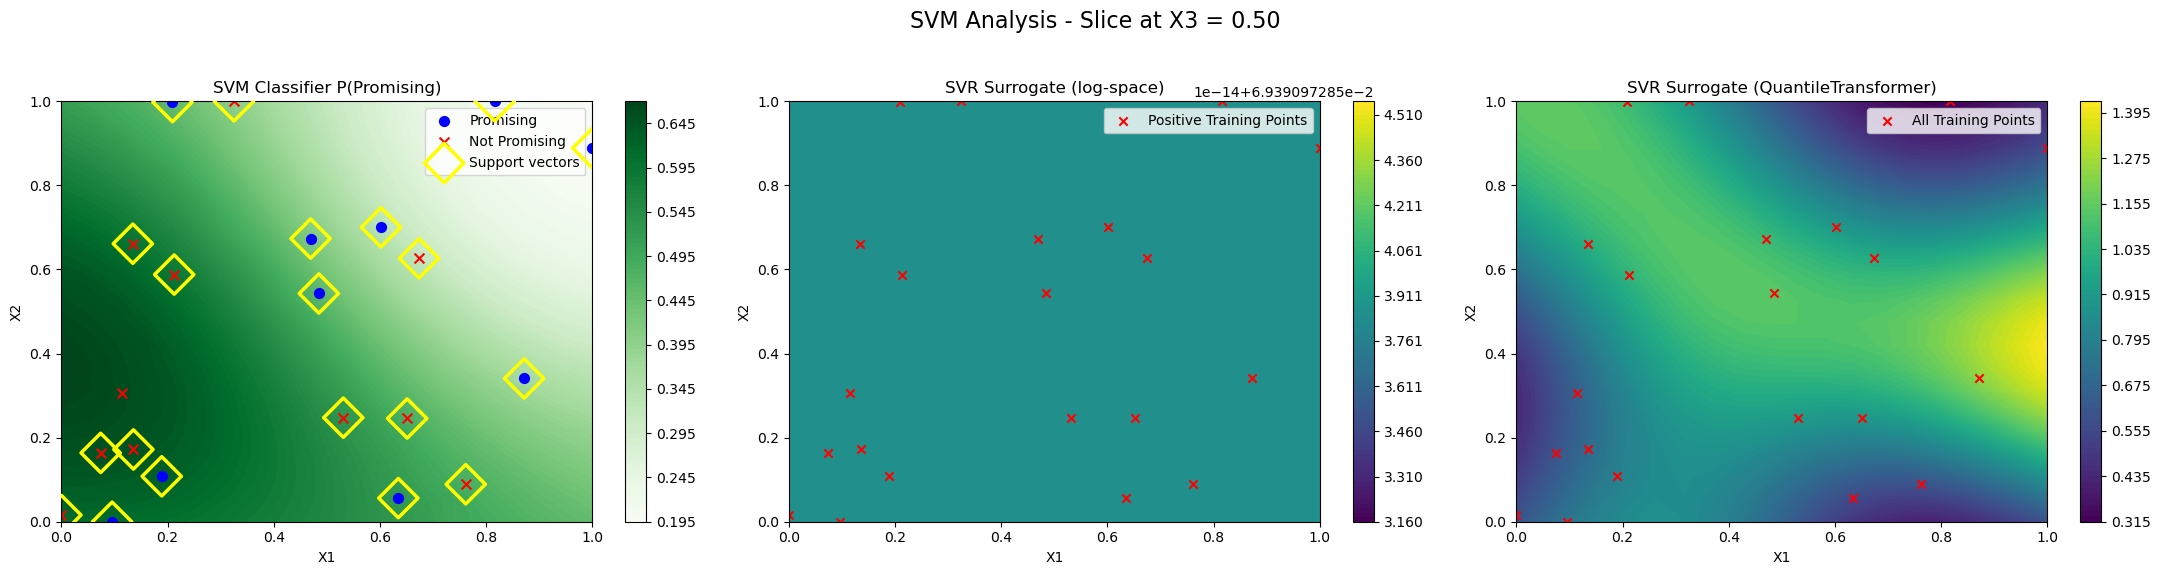

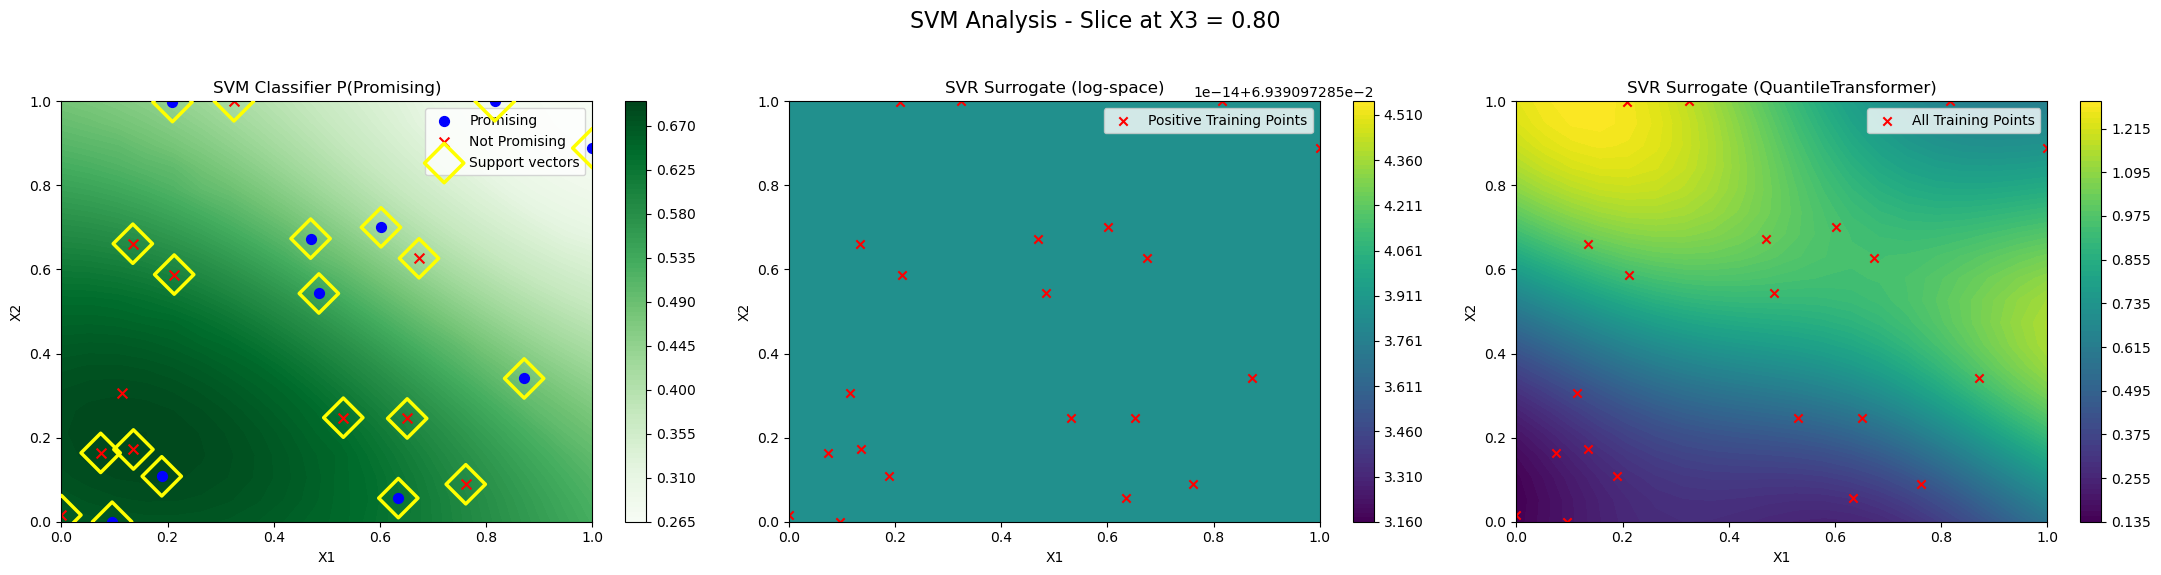

In [5]:
# --- 2a. SVM Classifier: promising vs not-promising regions ---
# C=1 (soft margin): prevents decision boundary from wrapping tightly around support vectors
# in the low-data regime (21 pts in 3D). C=10 was too aggressive — combined with a large
# gamma it caused boundary collapse to a narrow island.
# gamma=2.0: between 'auto' (too broad → flat P) and 'scale' (too local → boundary collapse).
svm_median_threshold = np.median(y_log_pos)
svm_labels = (y_log_pos > svm_median_threshold).astype(int)
n_pos = svm_labels.sum()
n_neg = len(svm_labels) - n_pos

print(f"SVM threshold: {svm_median_threshold:.4f} | {n_pos} promising / {n_neg} not promising")

svm_clf = SVC(kernel='rbf', C=1, gamma=2.0, probability=True)
svm_clf.fit(X_train, svm_labels)

# --- Support Vector Analysis ---
sv_indices = svm_clf.support_
support_vec_mask = np.zeros(len(X_train), dtype=bool)
support_vec_mask[sv_indices] = True

X_sv_orig = scaler_X.inverse_transform(X_train[sv_indices])
y_sv_raw  = y_train_raw[sv_indices]
sv_labels_vals = svm_labels[sv_indices]

print(f"\n=== Support Vectors: {len(sv_indices)} / {len(X_train)} training points ===")
print(f"{'Idx':>4}  {'Label':>12}  {'x1':>8}  {'x2':>8}  {'x3':>8}  {'y_raw':>12}")
for ti, x_o, y_o, lbl in zip(sv_indices, X_sv_orig, y_sv_raw, sv_labels_vals):
    coords = "  ".join(f"{v:>8.4f}" for v in x_o)
    print(f"{ti:>4}  {'promising' if lbl else 'not':>12}  {coords}  {y_o:>12.6f}")

# --- 2b. SVR Surrogate in log-space (all points) ---
svr_log = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=5.0)
svr_log.fit(X_train_pos, y_log_pos)

# --- 2c. SVR Surrogate on QuantileTransformer output (all points) ---
svr_qt = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
svr_qt.fit(X_train, y_qt)

# --- plotting for SVMs ---
def plot_svm_slices(x3_slice):
    grid_slice = np.c_[X_grid[:, 0], X_grid[:, 1], np.full_like(X_grid[:, 0], x3_slice)]

    svm_proba_slice = svm_clf.predict_proba(grid_slice)[:, 1]
    mu_svr_log_slice = svr_log.predict(grid_slice)
    mu_svr_qt_slice = svr_qt.predict(grid_slice)

    X_train_neg = np.empty((0, X_train.shape[1]))  # no excluded points

    plot_svm_analysis_slice(
        X1_test[:,:,0], X2_test[:,:,0],
        svm_proba_slice.reshape(n_grid, n_grid, n_grid)[:,:, int(x3_slice*(n_grid-1))],
        mu_svr_log_slice.reshape(n_grid, n_grid, n_grid)[:,:, int(x3_slice*(n_grid-1))],
        mu_svr_qt_slice.reshape(n_grid, n_grid, n_grid)[:,:, int(x3_slice*(n_grid-1))],
        X_train, X_train_pos, X_train_neg, svm_labels, x3_slice,
        support_vec_mask=support_vec_mask
    )

for x3_val in [0.2, 0.5, 0.8]:
    plot_svm_slices(x3_val)

# 5. Acquisition Function (SVM-constrained UCB Ensemble)

We combine the GP predictions into a single acquisition function:
- **UCB**: We use Upper Confidence Bound to balance exploration and exploitation.
- **SVM constraint**: The UCB score is multiplied by the SVM's P(promising) to steer the search away from penalty zones.
- **2-GP ensemble**: We average the normalized, constrained UCB scores from both GPs (gp_qt, gp_log) for a robust recommendation.

**Note:** The SVR surrogates are kept for the SVM analysis (Section 4) as independent surface visualizations, but are excluded from the acquisition ensemble. SVRs lack native uncertainty estimates, and with only 21 points in 3D, synthetic uncertainty proxies (e.g. distance-based) consistently over-explore toward boundaries. The two GPs already provide model diversity through different preprocessing (QuantileTransformer vs log-space).

**SVM role**: Despite 100% support vectors (soft margin with C=1 swallows all 21 points in 3D), the SVM P(promising) still provides implicit boundary regularization — it dampens acquisition scores near the edges of the space where GP uncertainty is high but no promising data exists. Removing the SVM constraint causes the pure GP ensemble to boundary-chase (x2→1).

Noise dim: x1 (ls=1000 ceiling), fixed at training mean = 0.4279
Active dims for LHS: x2, x3
kappa = 3.6154 (week 7/13)


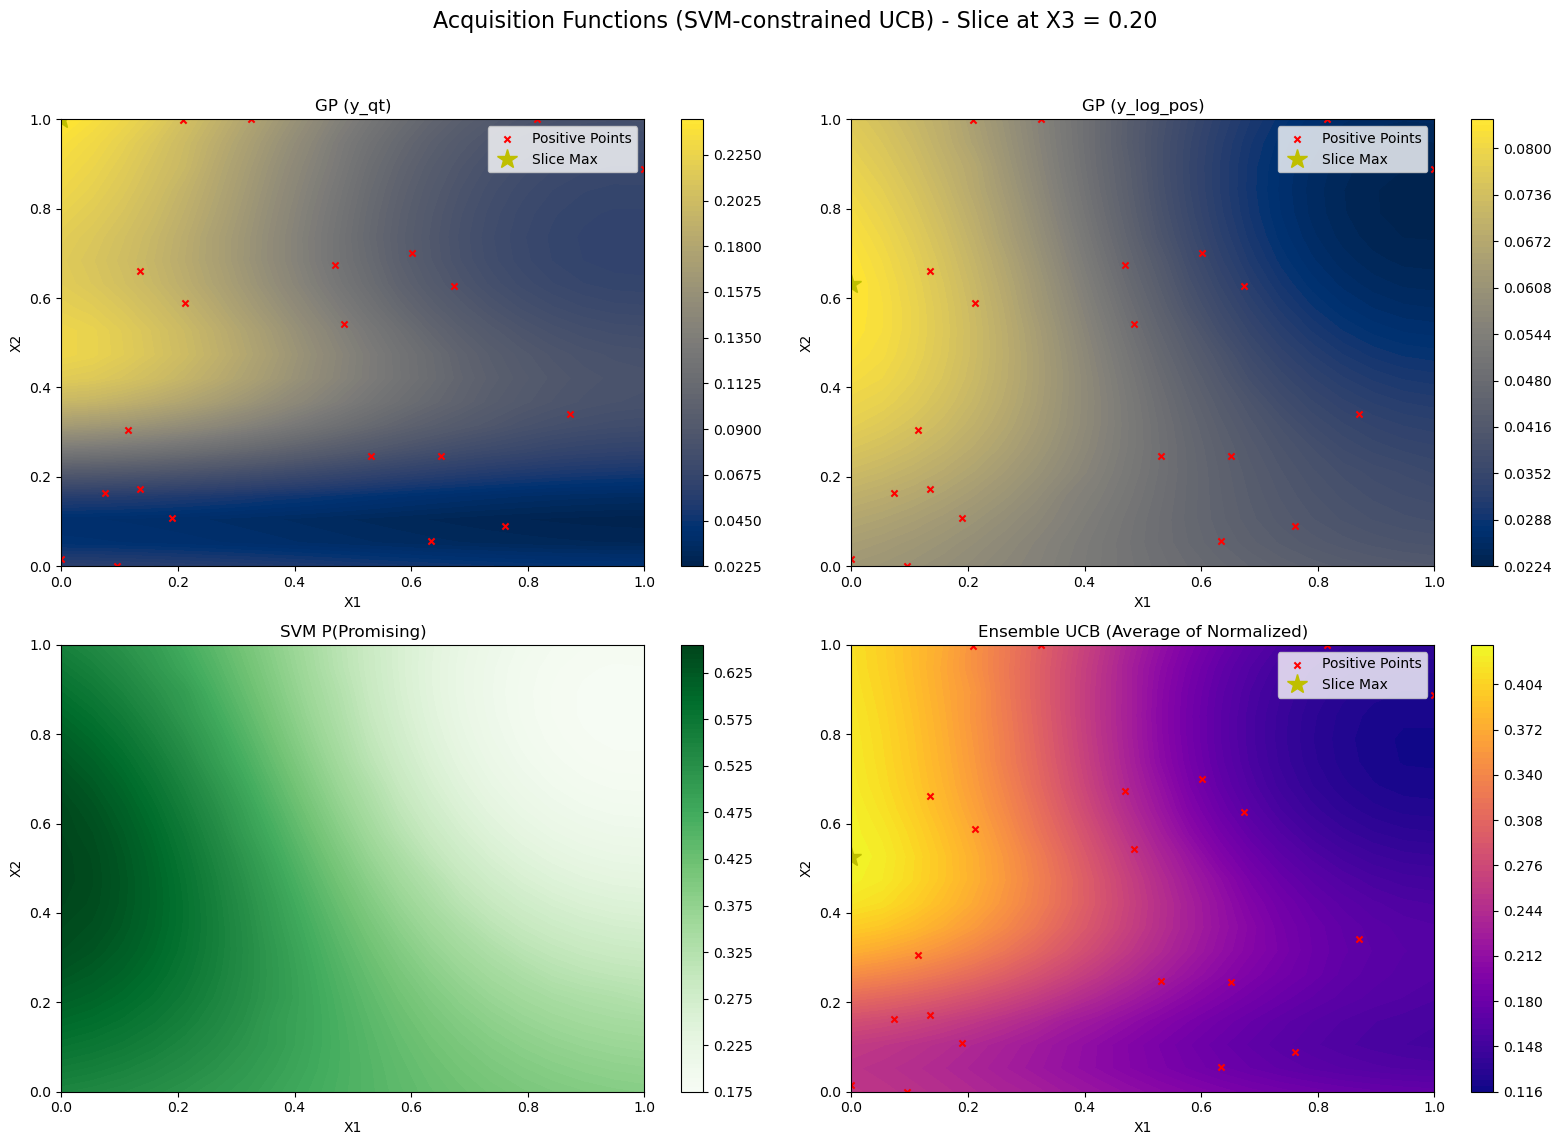

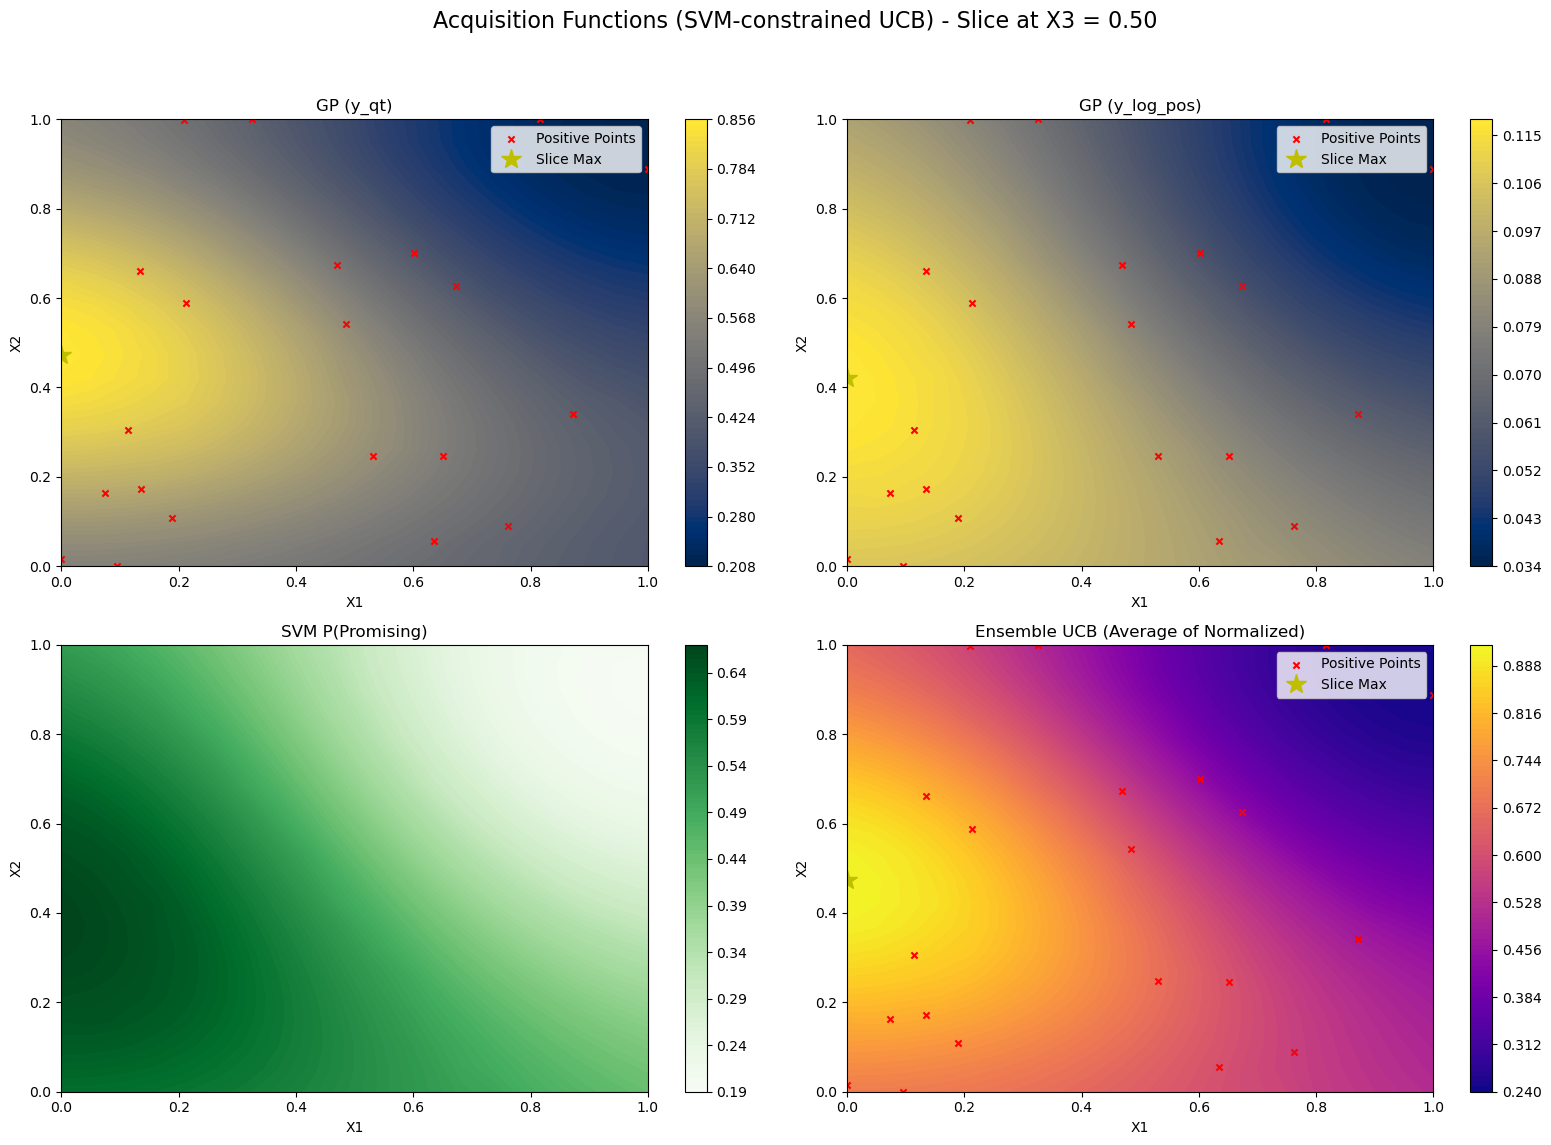

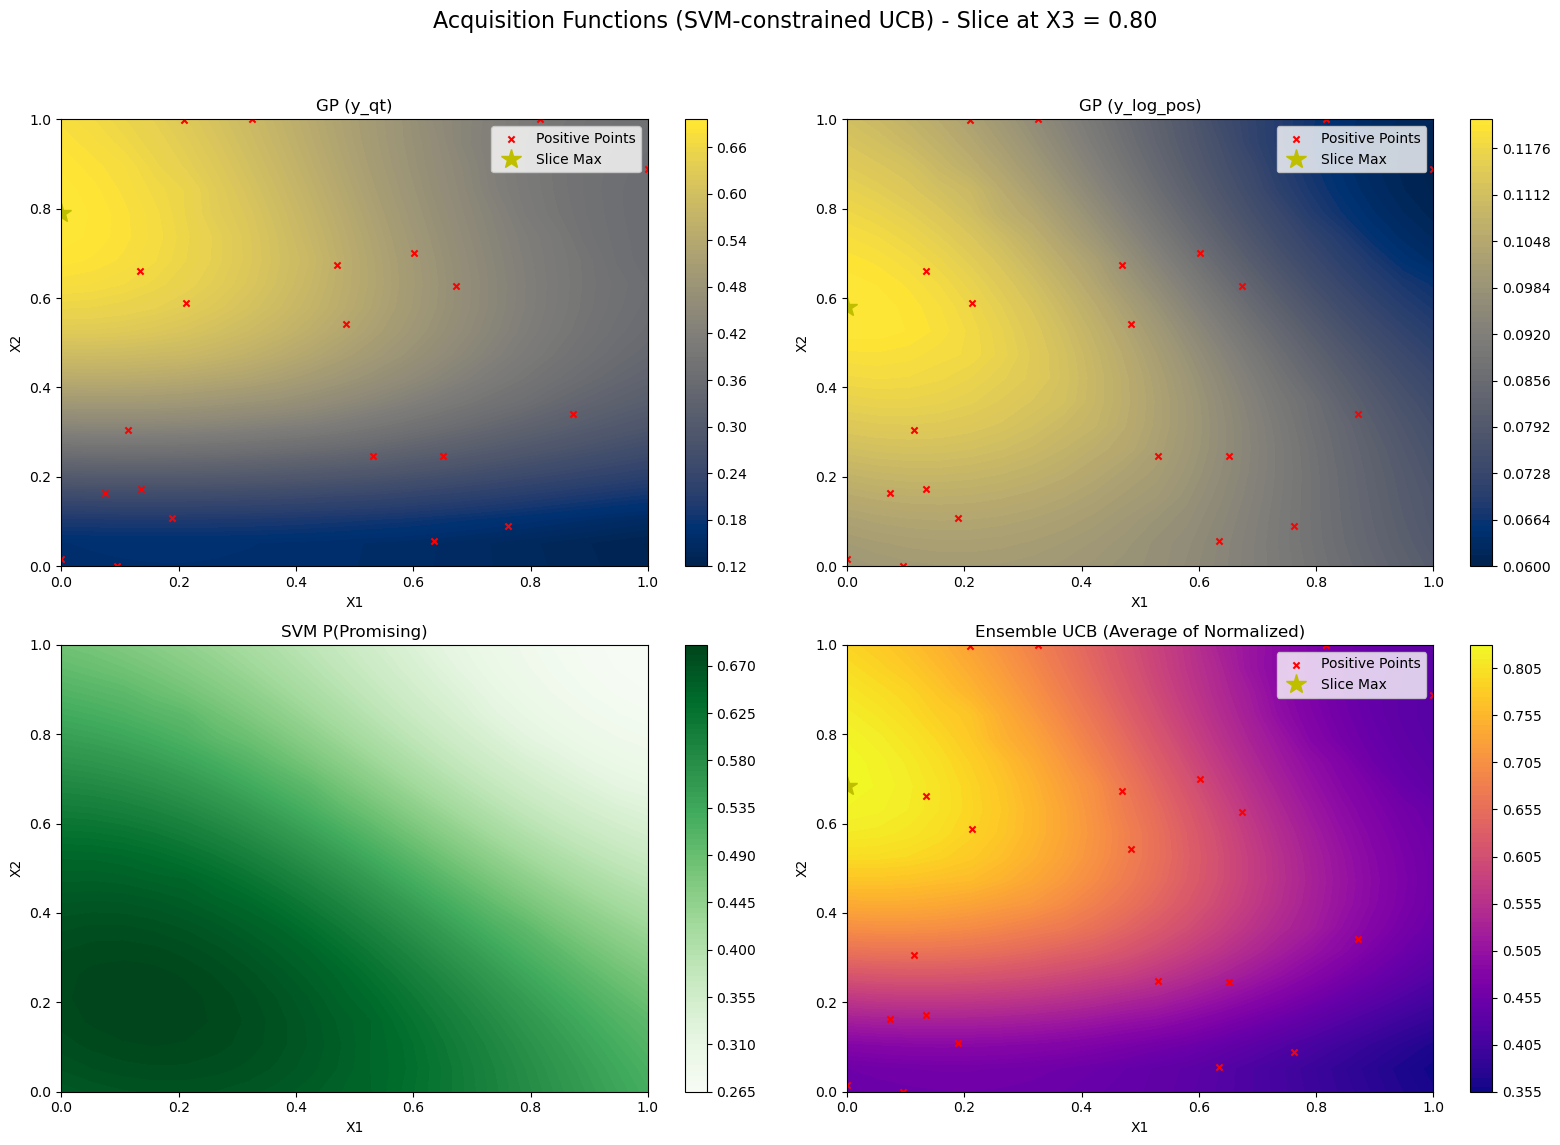

RECOMMENDED NEXT POINT (Ensemble of 2 GPs, 10K LHS in 2D active [x2,x3])
  Input (original space): [0.440142 0.422507 0.525903]
  SVM P(promising):       0.566

Individual surrogate suggestions:
    GP (y_qt)           : [0.440142 0.515041 0.493538], SVM P=0.528)
    GP (y_log_pos)      : [0.440142 0.282221 0.854142], SVM P=0.675)

Sanity check - is this a corner?
  x1 = 0.4279 (noise dim, fixed at training mean)
  x2 = 0.2808 
  x3 = 0.4972 

Current best: [0.848043 0.465799 0.395813] (y = -0.022407351804554693)

  SVM grid coverage: 41.6% promising (fail-safe threshold: 5%)
  SVM effective weights: SVM P(promising)

SUBMISSION: 0.440142-0.422507-0.525903


In [6]:
def upper_confidence_bound(mu, sigma, kappa=2.0):
    return mu + kappa * sigma

def constrained_ucb(ucb_vals, svm_proba):
    ucb_shifted = ucb_vals - ucb_vals.min() + 1e-6
    return ucb_shifted * svm_proba

def normalize_01(arr):
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-10)

# Noise dim confirmed this week: x1 ls=1000 (ceiling) in gp_qt, ls=16.88 in gp_log.
# Drop x1 from LHS search — same pattern as Fn7's x3 drop.
noise_dim_idx  = 0          # x1 confirmed noise
active_dims_acq = [1, 2]    # x2, x3 only
x1_fixed = X_train[:, noise_dim_idx].mean()
print(f"Noise dim: x1 (ls=1000 ceiling), fixed at training mean = {x1_fixed:.4f}")
print(f"Active dims for LHS: x2, x3")

# 2D LHS over active dims, reconstruct full 3D candidates for GP + SVM
sampler = LatinHypercube(d=2, seed=42)
X_cand_active = sampler.random(n=10_000)

X_candidates = np.zeros((10_000, 3))
X_candidates[:, 1] = X_cand_active[:, 0]   # x2
X_candidates[:, 2] = X_cand_active[:, 1]   # x3
X_candidates[:, 0] = x1_fixed              # x1 fixed

# Budget-aware kappa: linear decay from 5.0 (week 1) to 2.0 (week 13)
WEEK = 7
kappa = 5.0 - ((WEEK - 1) / 13) * 3.0
print(f"kappa = {kappa:.4f} (week {WEEK}/13)")

# GP predictions on LHS candidates
mu_gp_qt, sigma_gp_qt = gp_qt.predict(X_candidates, return_std=True)
mu_gp_log, sigma_gp_log = gp_log.predict(X_candidates, return_std=True)

# SVM probability (constraint)
svm_proba = svm_clf.predict_proba(X_candidates)[:, 1]

# SVM fail-safe — if SVM collapses to classify <5% of candidates as promising,
# fall back to uniform weights so the constraint doesn't silence the acquisition surface.
if (svm_proba > 0.5).mean() < 0.05:
    print("WARNING: SVM classified <5% of candidates as promising — applying fail-safe (uniform weights).")
    svm_proba_effective = np.ones_like(svm_proba)
else:
    svm_proba_effective = svm_proba

# UCB scores
ucb_gp_qt = upper_confidence_bound(mu_gp_qt, sigma_gp_qt, kappa=kappa)
ucb_gp_log = upper_confidence_bound(mu_gp_log, sigma_gp_log, kappa=kappa)

# SVM-constrained UCB
ucb_c_gp_qt = constrained_ucb(ucb_gp_qt, svm_proba_effective)
ucb_c_gp_log = constrained_ucb(ucb_gp_log, svm_proba_effective)

# Ensemble: average the 2 normalized constrained GP UCBs
ensemble_ucb = (normalize_01(ucb_c_gp_qt) + normalize_01(ucb_c_gp_log)) / 2.0

best_ensemble_idx = np.argmax(ensemble_ucb)
x_next_norm = X_candidates[best_ensemble_idx]
x_next_orig = scaler_X.inverse_transform([x_next_norm])[0]

# Find best point per surrogate for reporting
surrogates = {
    'GP (y_qt)': ucb_c_gp_qt,
    'GP (y_log_pos)': ucb_c_gp_log,
}
best_points = {}
for name, ucb_vals in surrogates.items():
    idx = np.argmax(ucb_vals)
    best_points[name] = {
        'idx': idx,
        'norm': X_candidates[idx],
        'orig': scaler_X.inverse_transform([X_candidates[idx]])[0],
        'svm_p': svm_proba[idx],
    }

# --- Plotting Slices (using grid for visualization) ---
svm_proba_grid = svm_clf.predict_proba(X_grid)[:, 1]
mu_qt_grid, sigma_qt_grid = gp_qt.predict(X_grid, return_std=True)
mu_log_grid, sigma_log_grid = gp_log.predict(X_grid, return_std=True)
ucb_qt_grid = constrained_ucb(upper_confidence_bound(mu_qt_grid, sigma_qt_grid, kappa), svm_proba_grid)
ucb_log_grid = constrained_ucb(upper_confidence_bound(mu_log_grid, sigma_log_grid, kappa), svm_proba_grid)
ensemble_grid = (normalize_01(ucb_qt_grid) + normalize_01(ucb_log_grid)) / 2.0

surrogates_grid = {
    'GP (y_qt)': ucb_qt_grid,
    'GP (y_log_pos)': ucb_log_grid,
}

def plot_acquisition_slices(x3_slice):
    _slice_idx = int(x3_slice * (n_grid - 1))
    surrogate_slices = {name: val.reshape(n_grid, n_grid, n_grid)[:, :, _slice_idx] for name, val in surrogates_grid.items()}
    svm_proba_slice = svm_proba_grid.reshape(n_grid, n_grid, n_grid)[:, :, _slice_idx]
    ensemble_ucb_slice = ensemble_grid.reshape(n_grid, n_grid, n_grid)[:, :, _slice_idx]
    X_train_neg = np.empty((0, X_train.shape[1]))
    plot_acquisition_comparison_slice(
        X1_test[:,:,0], X2_test[:,:,0],
        surrogate_slices, svm_proba_slice, ensemble_ucb_slice,
        X_train_pos, X_train_neg,
        x3_slice_val=x3_slice
    )

for x3_val in [0.2, 0.5, 0.8]:
    plot_acquisition_slices(x3_val)

# --- Summary ---
print(f"{'='*80}")
print(f"RECOMMENDED NEXT POINT (Ensemble of 2 GPs, 10K LHS in 2D active [x2,x3])")
print(f"{'='*80}")
print(f"  Input (original space): {np.array_str(x_next_orig, precision=6)}")
print(f"  SVM P(promising):       {svm_proba[best_ensemble_idx]:.3f}")

print(f"\nIndividual surrogate suggestions:")
for name, bp in best_points.items():
    print(f"    {name:20s}: {np.array_str(bp['orig'], precision=6)}, SVM P={bp['svm_p']:.3f})")

print(f"\nSanity check - is this a corner?")
for i in range(3):
    if i == noise_dim_idx:
        print(f"  x{i+1} = {x_next_norm[i]:.4f} (noise dim, fixed at training mean)")
    else:
        at_boundary = x_next_norm[i] < 0.02 or x_next_norm[i] > 0.98
        print(f"  x{i+1} = {x_next_norm[i]:.4f} {'<-- BOUNDARY!' if at_boundary else ''}")

print(f"\nCurrent best: {X_train_raw[np.argmax(y_train_raw)]} (y = {y_train_raw.max()})")
print(f"\n  SVM grid coverage: {(svm_proba > 0.5).mean()*100:.1f}% promising (fail-safe threshold: 5%)")
print(f"  SVM effective weights: {'uniform (fail-safe)' if (svm_proba > 0.5).mean() < 0.05 else 'SVM P(promising)'}")

# Machine-readable tag for get_submission.py
print(f"\nSUBMISSION: {'-'.join(f'{x:.6f}' for x in x_next_orig)}")

In [7]:

import numpy as np
import os

base_dir = "/Users/luissilva/Code/Imperial colleague/imperial-college-ml-ai-capstone-project/notebooks/data"

functions = [2, 4, 5]
weeks = ['week_1', 'week_2', 'week_3', 'week_4', 'week_5', 'week_6', 'week_7']

for fn in functions:
    print(f"\n{'='*100}")
    print(f"FUNCTION {fn}")
    print(f"{'='*100}")
    
    for week in weeks:
        inputs_path = f"{base_dir}/{week}/function_{fn}/inputs.npy"
        outputs_path = f"{base_dir}/{week}/function_{fn}/outputs.npy"
        
        if os.path.exists(inputs_path) and os.path.exists(outputs_path):
            X = np.load(inputs_path)
            y = np.load(outputs_path)
            
            print(f"\n{week.upper()}")
            print(f"  Inputs shape: {X.shape}, Outputs shape: {y.shape}")
            print(f"  Data shape: {len(X)} points × {X.shape[1] if len(X.shape) > 1 else 1} dimensions")
            print(f"\n  {'Index':<6} | {'Inputs':<70} | {'Output':<15}")
            print(f"  {'-'*6}-+-{'-'*70}-+-{'-'*15}")
            
            for i in range(len(X)):
                if len(X.shape) > 1:
                    x_str = f"[{', '.join([f'{x:10.6f}' for x in X[i]])}]"
                else:
                    x_str = f"[{X[i]:10.6f}]"
                y_val = y[i] if isinstance(y[i], (int, float, np.number)) else y[i][0]
                print(f"  {i:<6} | {x_str:<70} | {y_val:>14.10f}")
        else:
            print(f"\n{week.upper()}: Files not found")



FUNCTION 2

WEEK_1
  Inputs shape: (10, 2), Outputs shape: (10,)
  Data shape: 10 points × 2 dimensions

  Index  | Inputs                                                                 | Output         
  -------+------------------------------------------------------------------------+----------------
  0      | [  0.665800,   0.123969]                                               |   0.5389961189
  1      | [  0.877791,   0.778628]                                               |   0.4205862396
  2      | [  0.142699,   0.349005]                                               |  -0.0656236244
  3      | [  0.845275,   0.711120]                                               |   0.2939929124
  4      | [  0.454647,   0.290455]                                               |   0.2149645101
  5      | [  0.577713,   0.771973]                                               |   0.0231055498
  6      | [  0.438166,   0.685018]                                               |   0.2446193440
 

In [8]:

import numpy as np
import os
import json

base_dir = "/Users/luissilva/Code/Imperial colleague/imperial-college-ml-ai-capstone-project/notebooks/data"

# First, let's create a summary showing data sizes and point counts across all weeks
print("DATA INVENTORY SUMMARY")
print("="*80)

for fn in [2, 4, 5]:
    print(f"\nFunction {fn}:")
    for week in ['week_1', 'week_2', 'week_3', 'week_4', 'week_5', 'week_6', 'week_7']:
        inputs_path = f"{base_dir}/{week}/function_{fn}/inputs.npy"
        outputs_path = f"{base_dir}/{week}/function_{fn}/outputs.npy"
        
        if os.path.exists(inputs_path) and os.path.exists(outputs_path):
            X = np.load(inputs_path)
            y = np.load(outputs_path)
            print(f"  {week}: {len(X):2d} points × {X.shape[1]} dims, y range [{y.min():.6e}, {y.max():.6e}]")



DATA INVENTORY SUMMARY

Function 2:
  week_1: 10 points × 2 dims, y range [-6.562362e-02, 6.112052e-01]
  week_2: 11 points × 2 dims, y range [-6.562362e-02, 6.112052e-01]
  week_3: 12 points × 2 dims, y range [-6.562362e-02, 6.112052e-01]
  week_4: 13 points × 2 dims, y range [-6.562362e-02, 6.112052e-01]
  week_5: 14 points × 2 dims, y range [-6.562362e-02, 6.112052e-01]
  week_6: 15 points × 2 dims, y range [-6.562362e-02, 6.112052e-01]
  week_7: 16 points × 2 dims, y range [-6.562362e-02, 6.112052e-01]

Function 4:
  week_1: 30 points × 4 dims, y range [-3.262566e+01, -4.025542e+00]
  week_2: 31 points × 4 dims, y range [-3.262566e+01, 4.013055e-01]
  week_3: 32 points × 4 dims, y range [-3.750974e+01, 4.013055e-01]
  week_4: 33 points × 4 dims, y range [-3.750974e+01, 4.013055e-01]
  week_5: 34 points × 4 dims, y range [-3.750974e+01, 4.013055e-01]
  week_6: 35 points × 4 dims, y range [-3.750974e+01, 4.013055e-01]
  week_7: 36 points × 4 dims, y range [-3.750974e+01, 4.013055e-01

In [9]:

import numpy as np
import os

base_dir = "/Users/luissilva/Code/Imperial colleague/imperial-college-ml-ai-capstone-project/notebooks/data"

def show_function_data(fn):
    print(f"\n{'='*100}")
    print(f"FUNCTION {fn} - ALL SUBMISSIONS BY WEEK")
    print(f"{'='*100}\n")
    
    weeks = ['week_1', 'week_2', 'week_3', 'week_4', 'week_5', 'week_6', 'week_7']
    all_X = None
    all_y = None
    
    for week_idx, week in enumerate(weeks):
        inputs_path = f"{base_dir}/{week}/function_{fn}/inputs.npy"
        outputs_path = f"{base_dir}/{week}/function_{fn}/outputs.npy"
        
        if os.path.exists(inputs_path) and os.path.exists(outputs_path):
            X = np.load(inputs_path)
            y = np.load(outputs_path)
            
            # Determine new points added this week
            if all_X is not None:
                new_start_idx = len(all_X)
                new_points = X[new_start_idx:]
                new_y = y[new_start_idx:]
            else:
                new_start_idx = 0
                new_points = X
                new_y = y
            
            all_X = X.copy()
            all_y = y.copy()
            
            print(f"{week.upper()} (Total: {len(X)} points)")
            print(f"New submissions in {week}:")
            if len(new_points) > 0:
                for i, (x, y_val) in enumerate(zip(new_points, new_y)):
                    x_str = ', '.join([f'{val:10.6f}' for val in x])
                    print(f"  Row {new_start_idx + i:2d}: [{x_str}]  =>  {y_val:14.10f}")
            else:
                print(f"  No new points")
            print()

show_function_data(2)
show_function_data(4)
show_function_data(5)



FUNCTION 2 - ALL SUBMISSIONS BY WEEK

WEEK_1 (Total: 10 points)
New submissions in week_1:
  Row  0: [  0.665800,   0.123969]  =>    0.5389961189
  Row  1: [  0.877791,   0.778628]  =>    0.4205862396
  Row  2: [  0.142699,   0.349005]  =>   -0.0656236244
  Row  3: [  0.845275,   0.711120]  =>    0.2939929124
  Row  4: [  0.454647,   0.290455]  =>    0.2149645101
  Row  5: [  0.577713,   0.771973]  =>    0.0231055498
  Row  6: [  0.438166,   0.685018]  =>    0.2446193440
  Row  7: [  0.341750,   0.028698]  =>    0.0387490152
  Row  8: [  0.338648,   0.213867]  =>   -0.0138576181
  Row  9: [  0.702637,   0.926564]  =>    0.6112052158

WEEK_2 (Total: 11 points)
New submissions in week_2:
  Row 10: [  0.802781,   0.926563]  =>    0.0310262116

WEEK_3 (Total: 12 points)
New submissions in week_3:
  Row 11: [  0.142699,   0.028698]  =>    0.0695579215

WEEK_4 (Total: 13 points)
New submissions in week_4:
  Row 12: [  0.142699,   0.926564]  =>   -0.0053602684

WEEK_5 (Total: 14 points)
New 